#### Importaçao de Bibliotecas

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import json
import seaborn as sns

#### Fase 1: Processo de extração e Integração

In [ ]:
#Leitura excel
df_metas = pd.read_excel('metas_vendas_2024.xlsx')
#print(df_metas)

#Leitura csv
df_satisfacao = pd.read_csv('pesquisa_satisfacao_clientes.csv')
#print(df_satisfacao.head())

#DataFrame de satisfação média por Filial. (Colocado aqui para melhor organização)
df_satisfacao_filial = df_satisfacao.groupby('Filial')['Nota'].mean().reset_index()
df_satisfacao_filial.rename(columns={'Nota': 'Satisfacao_Media'}, inplace=True)
#print(df_satisfacao_filial)


#Leitura Json / Criação da tabela Filial
df_custo = pd.read_json('custos_operacionais.json').T.reset_index()
df_custo.rename(columns={'index': 'Filial'}, inplace=True)
#print(df_custo)



#Leitura do Banco de dados
connection = sqlite3.connect('DataOrganized.db')
query = """
SELECT v.id_venda, v.data_venda, v.vendedor, v.filial, p.nome_produto, p.categoria, v.quantidade, v.preco_venda, p.preco_tabela
FROM vendas v
JOIN produtos p ON v.id_produto = p.id_produto;
"""
df_vendas_produtos = pd.read_sql_query(query, connection)
connection.close()
df_vendas_produtos.rename(columns={'filial': 'Filial'}, inplace=True)#estava diferente dos outros dataframes
#print(df_vendas_produtos.head())




##### Merge dos Dados

In [ ]:
# Merge vendas/produtos com metas de faturamento
df_vendas_metas = pd.merge(df_vendas_produtos, df_metas, on='Filial', how='left')
#print(df_vendas_metas.head())

# Merge anterior com custos operacionais
df_vendas_metas_custos = pd.merge(df_vendas_metas, df_custo, on='Filial', how='left')
#print(df_vendas_metas_custos.head())

# Merge final
df_final = pd.merge(df_vendas_metas_custos, df_satisfacao_filial, on='Filial', how='left')
#print(df_final.head())


df_final.rename(columns= {'preco_tabela' : 'Preco_Venda'}, inplace=True)
#print(df_final.head())
df_final.rename(columns = {'preco_venda': 'Preco_Tabela'}, inplace=True)
#print(df_final.head())
#Obs: O preço de tabela estava mais alto que o preço de venda


#### Fase 2 : Engenharia de Atributos (Cálculos de Negócio)

In [ ]:
# Calculos com pandas(Dataframe)/Criando as tabelas novas

df_final['Faturamento_Real'] = df_final['quantidade'] * df_final['Preco_Venda']
#print(df_final.head())

df_final['Margem_Bruta'] = (df_final['Preco_Venda'] - df_final['Preco_Tabela'])/ df_final['Preco_Venda']
#print(df_final.head())

df_final['Atingimento_Meta'] = df_final['Faturamento_Real'] / df_final['Meta_Faturamento']
#print(df_final.head())

df_final['Custo_Total'] = df_final[['Aluguel', 'Energia', 'Marketing', 'Logistica']].sum(axis=1)
#print(df_final.head())

df_final['Lucro_Liquido'] = df_final['Faturamento_Real'] - df_final['Custo_Total']
#print(df_final.head())


#### Fase 3 : Diagnóstico Estatístico Profundo (Para Cada Filial) 

In [ ]:
# Utilizando Pandas


medias = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].mean()
#print('Médias por filial:\n', medias.round(4))

medianas = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].median()
#print('\nMedianas por filial:\n', medianas.round(4))

desvios = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].std()
#print('\nDesvios padrão por filial:\n', desvios.round(4))

moda = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].agg(lambda x: x.mode().iloc[0])# nao funcionou mode() por causa do groupby
#print('\nModa por filial:\n', moda.round(4))

assimetria = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].skew()
#print('\nAssimetria por filial:\n', assimetria.round(4))

curtose = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].apply(pd.Series.kurt)#nao tinha funcionado kurtosis() por causa do groupby
#print('\nCurtose por filial:\n', curtose.round(4))

resumo_filial = df_final.groupby('Filial')[['Margem_Bruta', 'Lucro_Liquido', 'Satisfacao_Media']].describe()
#print(resumo_filial.round(2))



#### Entrega Final

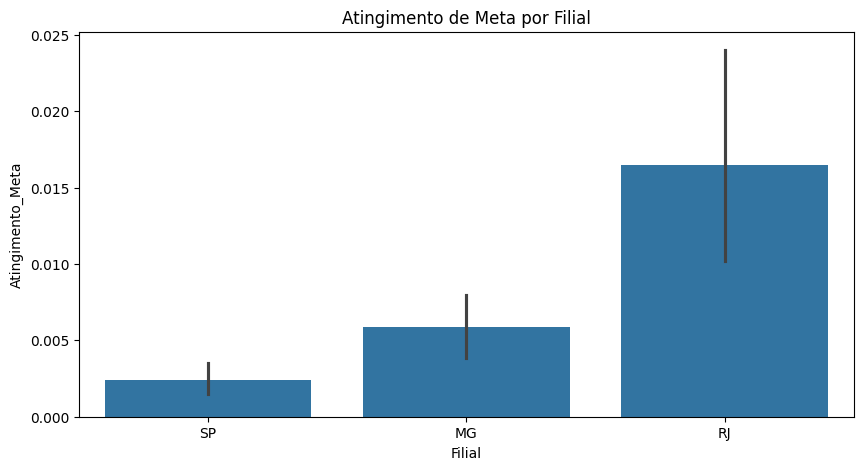

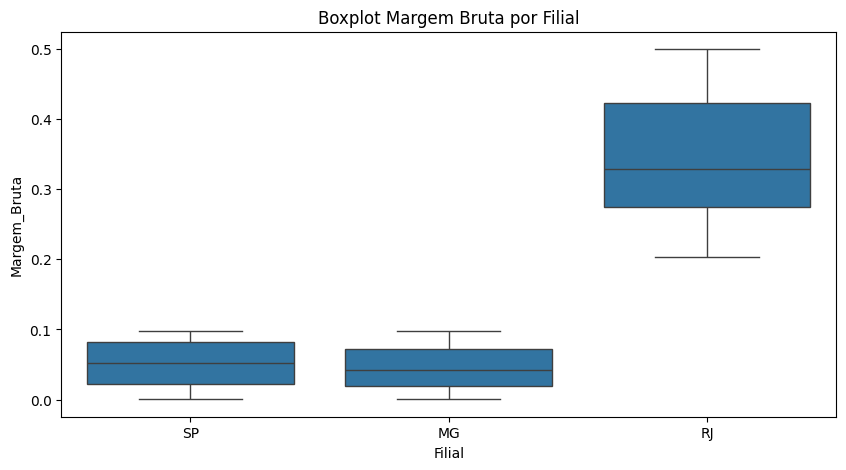

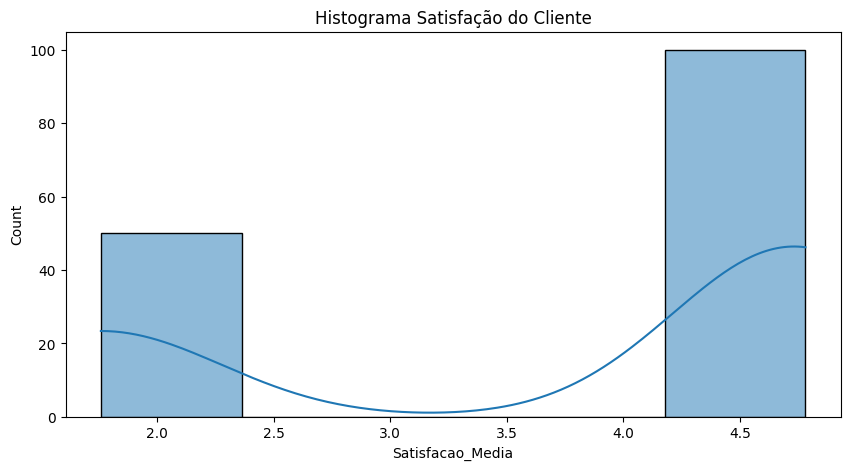

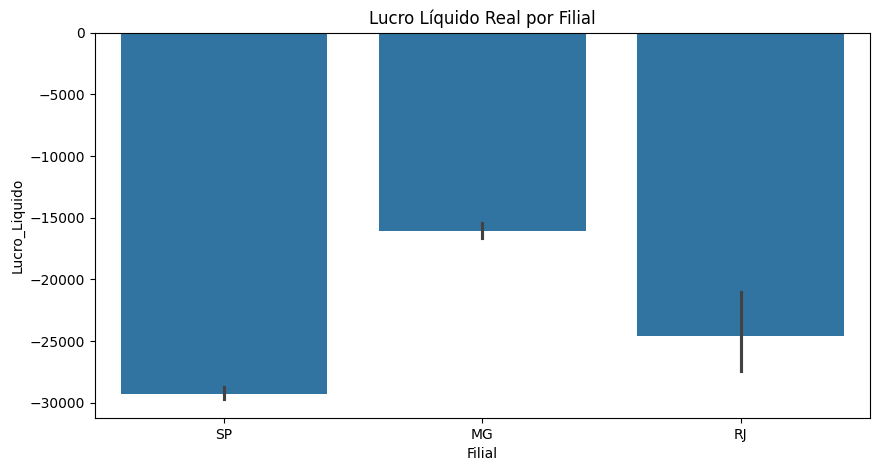

In [30]:
# Comparativo de Atingimento de Meta
plt.figure(figsize=(10,5))
sns.barplot(data=df_final, x='Filial', y='Atingimento_Meta')
plt.title('Atingimento de Meta por Filial')
plt.show()

# Boxplot Margem Bruta
plt.figure(figsize=(10,5))
sns.boxplot(data=df_final, x='Filial', y='Margem_Bruta')
plt.title('Boxplot Margem Bruta por Filial')
plt.show()

# Histograma Satisfação
plt.figure(figsize=(10,5))
sns.histplot(data=df_final, x='Satisfacao_Media', bins=5, kde=True)
plt.title('Histograma Satisfação do Cliente')
plt.show()

# Gráfico de barras Lucro Líquido
plt.figure(figsize=(10,5))
sns.barplot(data=df_final, x='Filial', y='Lucro_Liquido')
plt.title('Lucro Líquido Real por Filial')
plt.show()